In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
sns.set(style="whitegrid")

In [2]:
dataset=pd.read_csv("Mall_Customers.csv")
dataset.head(5)

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [3]:
x=dataset.iloc[:,[3,4]].values

<Figure size 1000x500 with 0 Axes>

<Figure size 1000x500 with 0 Axes>

<Figure size 1000x500 with 0 Axes>

<Figure size 1000x500 with 0 Axes>

<Figure size 1000x500 with 0 Axes>

<Figure size 1000x500 with 0 Axes>

<Figure size 1000x500 with 0 Axes>

<Figure size 1000x500 with 0 Axes>

<Figure size 1000x500 with 0 Axes>

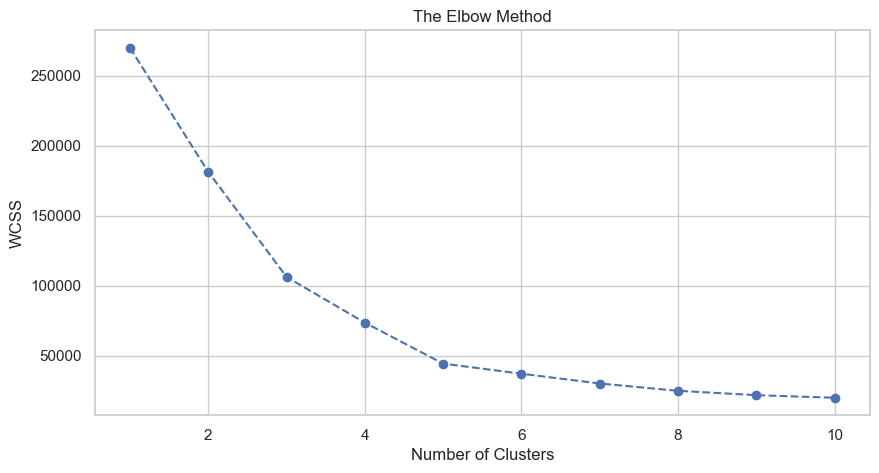

In [5]:
wcss=[]
for i in range(1,11):
    kmeans=KMeans(n_clusters=i,init="k-means++",random_state=42,n_init=10)    
    kmeans.fit(x)
    wcss.append(kmeans.inertia_)

    plt.figure(figsize=(10,5))
plt.plot(range(1,11),wcss, marker="o",linestyle="--")
plt.title("The Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

In [6]:
kmeans=KMeans(n_clusters=5,init="k-means++",random_state=42,n_init=10)
y_kmeans=kmeans.fit_predict(x)

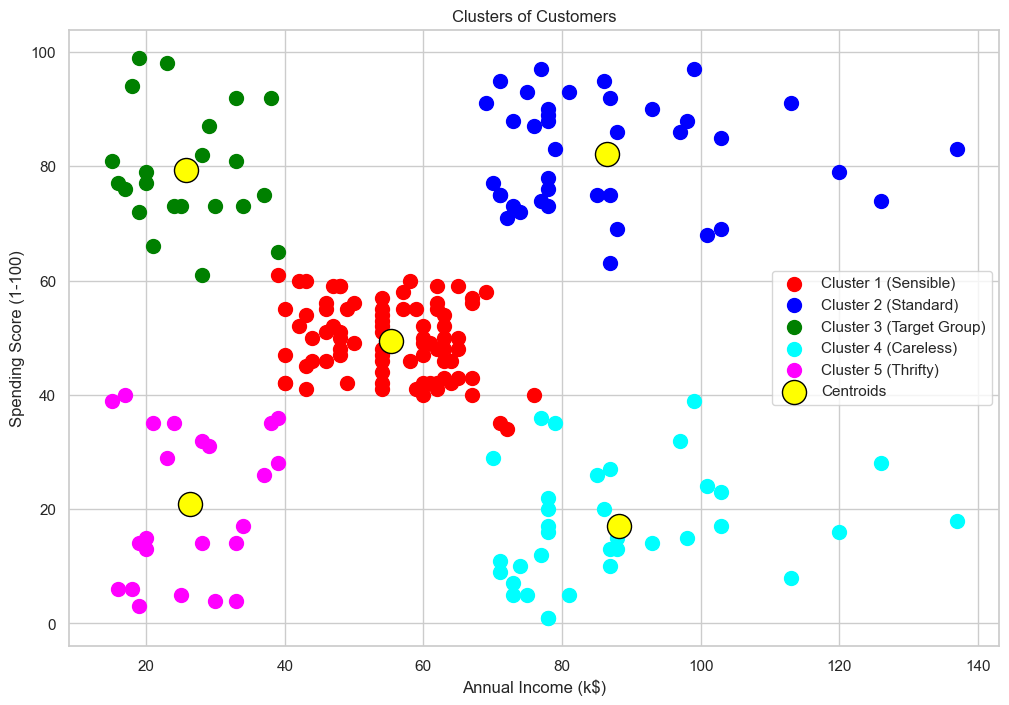

In [8]:
plt.figure(figsize=(12, 8))
plt.scatter(x[y_kmeans == 0, 0], x[y_kmeans == 0, 1], s=100, c='red', label='Cluster 1 (Sensible)')
plt.scatter(x[y_kmeans == 1, 0], x[y_kmeans == 1, 1], s=100, c='blue', label='Cluster 2 (Standard)')
plt.scatter(x[y_kmeans == 2, 0], x[y_kmeans == 2, 1], s=100, c='green', label='Cluster 3 (Target Group)')
plt.scatter(x[y_kmeans == 3, 0], x[y_kmeans == 3, 1], s=100, c='cyan', label='Cluster 4 (Careless)')
plt.scatter(x[y_kmeans == 4, 0], x[y_kmeans == 4, 1], s=100, c='magenta', label='Cluster 5 (Thrifty)')

# Plotting the centroids
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s=300, c='yellow', label='Centroids', edgecolors='black')

plt.title('Clusters of Customers')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.show()

In [9]:
def classify_customer():
    try:
        print("--- Market Segmentation Tool ---")
        income = int(input("Enter Annual Income in k$ (e.g., 80): "))
        spending = int(input("Enter Spending Score 1-100 (e.g., 20): "))

        # Predict cluster
        cluster = kmeans.predict([[income, spending]])[0]

        # Descriptive names for clusters based on visualization
        cluster_names = {
            0: "Sensible (High Income, Low Spending)",
            1: "Standard (Average Income, Average Spending)",
            2: "Target/Premium (High Income, High Spending)",
            3: "Careless (Low Income, High Spending)",
            4: "Careful (Low Income, Low Spending)"
        }

        print("\n" + "="*40)
        print(f"Result: This customer belongs to Group {cluster + 1}")
        print(f"Segment: {cluster_names[cluster]}")
        print("="*40)

    except ValueError:
        print("Invalid input! Please enter numbers for Income and Spending Score.")

# Call the function
classify_customer()

--- Market Segmentation Tool ---

Result: This customer belongs to Group 2
Segment: Standard (Average Income, Average Spending)
